In [ ]:
# !!!
DATASET_CSV = ""

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, 
    f1_score, roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("библиотеки загружены")

библиотеки загружены


In [58]:
# создание датафрейма
if DATASET_CSV:
    df = pd.read_csv(DATASET_CSV)
else:
    df = pd.read_csv('./data/dataset.csv')
    
print(f"размер: {df.shape}")
print(df.head())
print(df.isnull().sum())

NameError: name 'DATASET_CSV' is not defined

In [ ]:
# Распределение целевых переменных
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['CGPA'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('распределение cgpa')
df['Depression'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('распределение depression')
plt.tight_layout()
plt.show()

# Корреляционная матрица
plt.figure(figsize=(8, 6))
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_cols = [c for c in num_cols if c not in ['Student_ID', 'CGPA', 'Depression']]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('корреляция признаков')
plt.show()

In [51]:
# ПРЕДОБРАБОТКА!!!
df_proc = df.copy()

# 1. Удаление дубликатов
df_proc = df_proc.drop_duplicates()

# 2. Исправление логических ошибок
if (df_proc['Age'] < 0).any():
    median_age = df_proc[df_proc['Age'] > 0]['Age'].median()
    df_proc.loc[df_proc['Age'] < 0, 'Age'] = median_age

df_proc['CGPA'] = df_proc['CGPA'].clip(0, 10)

# Замена некорректных значений времени на NaN
for col in ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours']:
    mask = (df_proc[col] < 0) | (df_proc[col] > 24)
    if mask.any():
        df_proc.loc[mask, col] = np.nan

# 3. Заполнение пропусков
for col in df_proc.select_dtypes(include=np.number).columns:
    df_proc[col] = df_proc[col].fillna(df_proc[col].median())

for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = df_proc[col].fillna(df_proc[col].mode()[0])

# 4. Обработка выбросов (IQR метод)
def fix_outliers(df, col):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    df[col] = df[col].clip(q1 - 1.5*iqr, q3 + 1.5*iqr)
    return df

for col in ['CGPA', 'Sleep_Duration', 'Study_Hours', 'Stress_Level']:
    df_proc = fix_outliers(df_proc, col)

In [52]:
# Создание новых признаков
df_proc['Study_Social_Ratio'] = df_proc['Study_Hours'] / (df_proc['Social_Media_Hours'] + 1)
df_proc['Health_Index'] = df_proc['Physical_Activity'] + (10 - df_proc['Stress_Level'])
df_proc['Adequate_Sleep'] = ((df_proc['Sleep_Duration'] >= 7) & (df_proc['Sleep_Duration'] <= 9)).astype(int)

# Кодирование категориальных признаков
if 'Department' in df_proc.columns:
    df_proc = pd.get_dummies(df_proc, columns=['Department'], prefix='Dept', drop_first=True)

if 'Gender' in df_proc.columns and df_proc['Gender'].dtype == 'object':
    df_proc['Gender_Encoded'] = df_proc['Gender'].map({'Male': 0, 'Female': 1}).fillna(0)

# Списки признаков для моделей
feat_reg = ['Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 
            'Physical_Activity', 'Stress_Level', 'Study_Social_Ratio', 
            'Health_Index', 'Adequate_Sleep']
            
feat_clf = feat_reg + ['CGPA']

for col in df_proc.columns:
    if col.startswith('Dept_') or col == 'Gender_Encoded':
        if col not in feat_reg: feat_reg.append(col)
        if col not in feat_clf: feat_clf.append(col)

In [53]:
# --- Регрессия (CGPA) ---
X_reg = df_proc[feat_reg]
y_reg = df_proc['CGPA']
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)
X_val_r, X_test_r, y_val_r, y_test_r = train_test_split(X_te_r, y_te_r, test_size=0.5, random_state=42)

# --- Классификация (Depression) ---
X_clf = df_proc[feat_clf]
y_clf = df_proc['Depression']
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf)
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(X_te_c, y_te_c, test_size=0.5, random_state=42, stratify=y_te_c)

# Масштабирование (fit на train, transform на val/test)
scaler_r = StandardScaler().fit(X_tr_r)
X_tr_r_s = scaler_r.transform(X_tr_r)
X_val_r_s = scaler_r.transform(X_val_r)
X_test_r_s = scaler_r.transform(X_test_r)

scaler_c = StandardScaler().fit(X_tr_c)
X_tr_c_s = scaler_c.transform(X_tr_c)
X_val_c_s = scaler_c.transform(X_val_c)
X_test_c_s = scaler_c.transform(X_test_c)

In [ ]:
lr = LinearRegression().fit(X_tr_r_s, y_tr_r)
pred_test = lr.predict(X_test_r_s)

print(f"r2 score: {r2_score(y_test_r, pred_test):.4f}")
print(f"rmse: {np.sqrt(mean_squared_error(y_test_r, pred_test)):.4f}")

plt.scatter(y_test_r, pred_test, alpha=0.3)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.title('факт vs прогноз cgpa')
plt.show()

In [54]:
# Подбор гиперпараметров
best_c, best_iter = 1, 100
best_acc = 0

for c in [0.01, 0.1, 1, 10]:
    for it in [100, 500]:
        m = LogisticRegression(C=c, max_iter=int(it), solver='lbfgs', random_state=42)
        m.fit(X_tr_c_s, y_tr_c)
        acc = accuracy_score(y_val_c, m.predict(X_val_c_s))
        if acc > best_acc:
            best_acc = acc
            best_c, best_iter = c, int(it)

# Обучение финальной модели
clf = LogisticRegression(C=best_c, max_iter=best_iter, solver='lbfgs', random_state=42)
clf.fit(X_tr_c_s, y_tr_c)

pred_cls = clf.predict(X_test_c_s)
pred_proba = clf.predict_proba(X_test_c_s)[:, 1]

print(f"accuracy: {accuracy_score(y_test_c, pred_cls):.4f}")
print(f"f1 score: {f1_score(y_test_c, pred_cls):.4f}")
print(f"roc-auc: {roc_auc_score(y_test_c, pred_proba):.4f}")
print(classification_report(y_test_c, pred_cls))

accuracy: 0.8994
f1 score: 0.0000
roc-auc: 0.6875
              precision    recall  f1-score   support

       False       0.90      1.00      0.95     13491
        True       0.00      0.00      0.00      1509

    accuracy                           0.90     15000
   macro avg       0.45      0.50      0.47     15000
weighted avg       0.81      0.90      0.85     15000



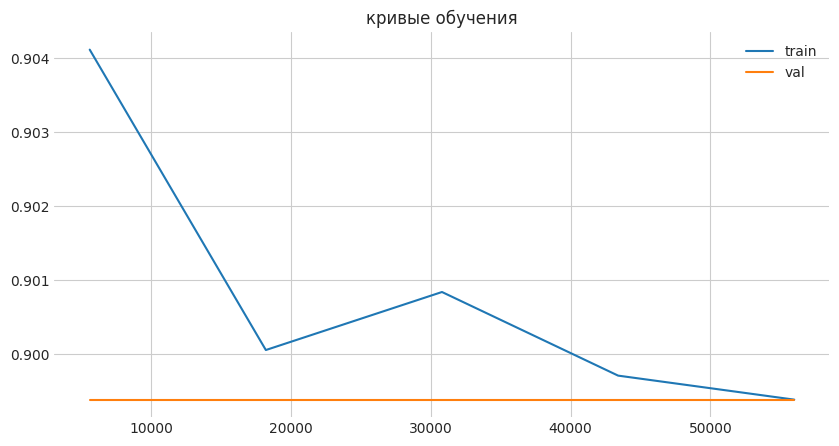

точность на train: 0.8994
точность на test: 0.8994
переобучения нет


In [55]:
# Кривые обучения
train_sizes, train_scores, val_scores = learning_curve(
    clf, X_tr_c_s, y_tr_c, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='val')
plt.title('кривые обучения')
plt.legend()
plt.show()

# Сравнение метрик
train_acc = accuracy_score(y_tr_c, clf.predict(X_tr_c_s))
test_acc = accuracy_score(y_test_c, pred_cls)

print(f"точность на train: {train_acc:.4f}")
print(f"точность на test: {test_acc:.4f}")

if abs(train_acc - test_acc) < 0.05:
    print("переобучения нет")
else:
    print("возможно переобучение")

### Ручное тестирование

In [ ]:
# Данные нового студента
input_data = {
    'Age': 20,
    'Gender': 'Male',
    'Department': 'Computer Science',
    'Sleep_Duration': 7.0,
    'Study_Hours': 5.0,
    'Social_Media_Hours': 2.0,
    'Physical_Activity': 3.0,
    'Stress_Level': 6.0
}

new_student = pd.DataFrame([input_data])

# 1. Кодирование и Feature Engineering (повторяем логику из Ячейки 4)
if 'Department' in new_student.columns:
    new_student = pd.get_dummies(new_student, columns=['Department'], prefix='Dept', drop_first=True)

if 'Gender' in new_student.columns:
    new_student['Gender_Encoded'] = new_student['Gender'].map({'Male': 0, 'Female': 1}).fillna(0)
    new_student.drop(columns=['Gender'], inplace=True, errors='ignore')

new_student['Study_Social_Ratio'] = new_student['Study_Hours'] / (new_student['Social_Media_Hours'] + 1)
new_student['Health_Index'] = new_student['Physical_Activity'] + (10 - new_student['Stress_Level'])
new_student['Adequate_Sleep'] = ((new_student['Sleep_Duration'] >= 7) & (new_student['Sleep_Duration'] <= 9)).astype(int)

# 2. Выравнивание столбцов (добавляем недостающие нулями)
for col in feat_reg:
    if col not in new_student.columns:
        new_student[col] = 0
for col in feat_clf:
    if col not in new_student.columns:
        new_student[col] = 0

# Отбираем нужные колонки в правильном порядке
X_new_r = new_student[feat_reg]
X_new_c = new_student[feat_clf]

# 3. Масштабирование (используем уже обученные scaler)
X_new_r_s = scaler_r.transform(X_new_r)
X_new_c_s = scaler_c.transform(X_new_c)

# 4. Прогноз
pred_cgpa = lr.predict(X_new_r_s)[0]
pred_dep_class = clf.predict(X_new_c_s)[0]
pred_dep_prob = clf.predict_proba(X_new_c_s)[0][1]

print(f"прогноз cgpa: {pred_cgpa:.2f}")
print(f"риск депрессии: {'да' if pred_dep_class == 1 else 'нет'} (вероятность {pred_dep_prob:.2%})")